In [1]:
# LVDT_simulation/tests/run_simulation.ipynb
import sys
sys.path.append('..')
from simulation.simulator import setup_logging, SimulatorManager
from simulation import data_generator


In [2]:
sim_manager = SimulatorManager(
    input_config_json='config_lvdt.json',
    output_dir='../data',
    output_config_json='lvdt_alushell_magnet.json',
    output_data_hdf5='lvdt_alushell_magnet.hdf5',
    auto_close=False
)
sim_manager.run_simulation()

In [3]:
import h5py
import numpy as np
from scipy.stats import linregress
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def get_data(hdf5_file_path):
    with h5py.File(hdf5_file_path, "r") as hdf5_file:
        position_data = np.array(hdf5_file["position"])
        coil_data = {"position": position_data}
        
        for coil_name in hdf5_file.keys():
            if coil_name != "position":
                coil_data[coil_name] = {}
                for attribute in hdf5_file[coil_name].keys():
                    data_array = np.array(hdf5_file[coil_name][attribute])
                    
                    if attribute == "voltage" and np.iscomplexobj(data_array):
                        coil_data[coil_name]["voltage"] = data_array
                        coil_data[coil_name]["voltage_real"] = data_array.real
                        coil_data[coil_name]["voltage_imag"] = data_array.imag
                        
                        # Compute absolute value and adjust sign for first half
                        abs_data = np.abs(data_array)
                        abs_data[:1+len(abs_data)//2] *= -1  # Flip sign for first half
                        coil_data[coil_name]["voltage_abs"] = abs_data
                    else:
                        coil_data[coil_name][attribute] = data_array
    return coil_data

def linear_model(x, a, b):
    return a * x + b

def compute_sensitivity_curvefit(position, voltage_abs):
    params, _ = curve_fit(linear_model, position, voltage_abs)
    return {"slope": params[0], "intercept": params[1]}

def compute_sensitivity_linregress(position, voltage_abs):
    slope, intercept, r_value, p_value, std_err = linregress(position, voltage_abs)
    return {"slope": slope, "intercept": intercept, "r_value": r_value, "p_value": p_value, "std_err": std_err}

def compute_error_metrics(real_voltage, predicted_voltage):
    residuals = real_voltage - predicted_voltage
    mse = np.mean(residuals**2)
    r_squared = 1 - (np.sum(residuals**2) / np.sum((real_voltage - np.mean(real_voltage))**2))
    return {"residuals": residuals, "mse": mse, "r_squared": r_squared}

def plot_fitted_vs_simulation(position, real_voltage, predicted_voltages, coil_name):
    plt.figure(figsize=(8, 5))
    # plt.scatter(position, real_voltage, color='blue', marker="o", label="Real Voltage")
    for key in predicted_voltages:
        plt.scatter(position, predicted_voltages[key], marker="o", label=f"Fitted Voltage ({key})")
    plt.xlabel("Position (mm)")
    plt.ylabel("Voltage (V)")
    plt.title(f"Fitted vs. Simulated Voltage ({coil_name})")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_residuals(position, residuals, coil_name):
    plt.figure(figsize=(8, 5))
    plt.scatter(position, residuals, color='purple', marker="o", label="Residuals")
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel("Position (mm)")
    plt.ylabel("Residuals (V)")
    plt.title(f"Residuals Plot ({coil_name})")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_residual_histogram(residuals, coil_name):
    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=20, color='orange', edgecolor='black', alpha=0.7)
    plt.xlabel("Residuals (V)")
    plt.ylabel("Frequency")
    plt.title(f"Residual Histogram ({coil_name})")
    plt.grid(True)
    plt.show()

def compute_sensitivity_for_coil(data, coil_name):
    if coil_name not in data or "voltage_abs" not in data[coil_name]:
        raise ValueError(f"Coil {coil_name} not found in data or missing voltage_abs attribute.")
    
    linregress_result = compute_sensitivity_linregress(data["position"], data[coil_name]["voltage_abs"])
    lin_predicted_voltage = linear_model(data["position"], linregress_result["slope"], linregress_result["intercept"])
    curvefit_result = compute_sensitivity_curvefit(data["position"], data[coil_name]["voltage_abs"])
    cur_predicted_voltage = linear_model(data["position"], curvefit_result["slope"], curvefit_result["intercept"])    
    fitted_voltages = {"linregress": lin_predicted_voltage, "curvefit": cur_predicted_voltage}
    # Plot the fitted vs. real voltage data
    plot_fitted_vs_simulation(data["position"], data[coil_name]["voltage_abs"], fitted_voltages, coil_name)


In [4]:
# datafile1 = '../data/lvdt_alucore_no_magnet.hdf5'
# datafile2 = '../data/lvdt_alucore_with_magnet.hdf5'
datafile3 = '../data/lvdt_alucore_with_magnet_only.hdf5'

# lvdt_data1 = get_data(datafile1)
# lvdt_data2 = get_data(datafile2)
lvdt_data3 = get_data(datafile3)
coil_name = "Middle_Coil"  # Specify the coil name


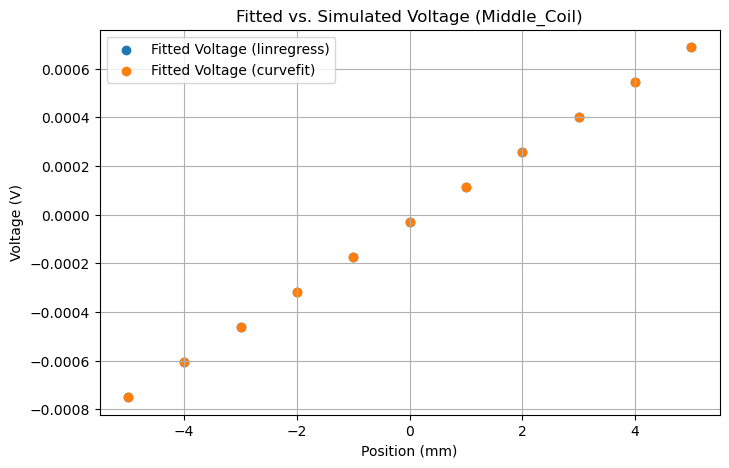

In [ ]:
compute_sensitivity_for_coil(lvdt_data3, coil_name)
